# Homework #1 - MongoDB

### #1 Caricamento dati

In [1]:
# Import librerie
import pandas as pd
from pymongo import MongoClient
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# DB Connection
client = MongoClient("mongodb://localhost:27017/")
db = client["amazon-food-reviews"]

In [ ]:
# Pulisce eventuali vecchie collezioni
for name in ["score1", "score2", "score3", "score4", "score5", "no_text"]:
    db[name].drop()

In [ ]:
# Legge il CSV Kaggle
df = pd.read_csv("archive/Reviews.csv")

for _, row in df.iterrows():
    product_id = row.get("ProductId")
    user_id = row.get("UserId")
    profile_name = row.get("ProfileName")
    score = row.get("Score")
    summary = row.get("Summary")
    text = row.get("Text")
    time_value = row.get("Time")

    summary = "" if pd.isna(summary) else str(summary).strip()
    text = "" if pd.isna(text) else str(text).strip()
    profile_name = "" if pd.isna(profile_name) else str(profile_name)

    time_value = "" if pd.isna(time_value) else str(time_value)

    doc = {
        "product_id": str(product_id) if not pd.isna(product_id) else "",
        "user_id": str(user_id) if not pd.isna(user_id) else "",
        "profile_name": profile_name,
        "score": int(score) if not pd.isna(score) else None,
        "summary": summary,
        "text": text,
        "time": time_value,
        "sentiment": None   # parametro per Vader
    }

    if summary == "" or text == "":
        db["no_text"].insert_one(doc)
    else:
        if doc["score"] in [1, 2, 3, 4, 5]:
            db[f"score{doc['score']}"].insert_one(doc)

print("Import completato.")

### #2 Sentiment Analysis

In [ ]:
# Initialization Vader
analyzer = SentimentIntensityAnalyzer()

def analyze_sentiment_vader(text):
    scores = analyzer.polarity_scores(text)
    compound = scores["compound"]
    if compound >= 0.05:
        return "pos"
    elif compound <= -0.05:
        return "neg"
    else:
        return "neu"

In [ ]:
# Sentiment analyses
scores = {"score1", "score2", "score3", "score4", "score5"}

for score in scores:
    collection = db[score]

    for review in collection.find():
        summary = review.get("summary", "")
        text = review.get("text", "")
        full_text = f"{summary} {text}".strip() # vader basato su summary e text

        sentiment = analyze_sentiment_vader(full_text)

        collection.update_one(
            {"_id": review["_id"]},
            {"$set": {"sentiment": sentiment}}
        )

    #print(f"Post ID {review['_id']} classified: {sentiment}")

### #3 Interrogazioni analitiche

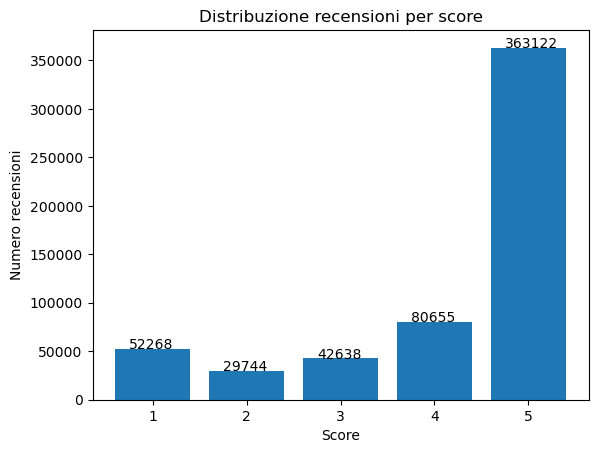

In [24]:
# Numero recensioni per score nell'istogramma
scores = ["score1", "score2", "score3", "score4", "score5"]
counters = []

for score in scores:
    counter = db[score].count_documents({})
    counters.append(counter)

plt.bar([1,2,3,4,5], counters)

# https://stackoverflow.com/questions/53066633/how-to-show-values-on-top-of-bar-plot
xlocs, xlabs = plt.xticks()
xlocs=[i+1 for i in range(0,5)]
xlabs=[i/2 for i in range(0,5)]
for i, v in enumerate(counters):
    plt.text(xlocs[i] - 0.25, v + 0.01, str(v))

plt.xlabel("Score")
plt.ylabel("Numero recensioni")
plt.title("Distribuzione recensioni per score")
plt.show()

In [25]:
# Trovare 5 prodotti con la media di score più alta
product_scores = defaultdict(list)

scores = ["score1","score2","score3","score4","score5"]

for s in scores:
    for r in db[s].find({}, {"product_id":1, "score":1}): # seleziono solo product_id e score
        product_scores[r["product_id"]].append(r["score"]) # salvo tutti score per quel prodotto [key->value]

avg_scores = []

for product, scores in product_scores.items():
    #print(f"product_id: {product} - scores: {scores}")
    avg = sum(scores)/len(scores)
    avg_scores.append((product, avg))

top5 = sorted(avg_scores, key=lambda x: x[1], reverse=True)[:5]

for p in top5:
    print(p)

('B001E4KFG0', 5.0)
('B000E7L2R4', 5.0)
('B00171APVA', 5.0)
('B0001PB9FE', 5.0)
('B00144C10S', 5.0)


In [26]:
# Trovare i 5 utenti che hanno scritto più recensioni
user_review = defaultdict(list)

scores = ["score1","score2","score3","score4","score5"]

for s in scores:
    for r in db[s].find({}, {"user_id":1, "score":1}): # seleziono solo user_id e score
        user_review[r["user_id"]].append(r["score"]) # salvo tutti score per quel prodotto [key->value]
        

max_user_review = []

for user, scores in user_review.items():
    #print(f"user_id: {user} - scores: {scores}")
    max_user_review.append((user, len(scores)))

top5 = sorted(max_user_review, key=lambda x: x[1], reverse=True)[:5]

for p in top5:
    print(p)

('A3OXHLG6DIBRW8', 448)
('A1YUL9PCJR3JTY', 421)
('AY12DBB0U420B', 389)
('A281NPSIMI1C2R', 365)
('A1Z54EM24Y40LL', 256)


In [27]:
# Calcolare il numero di recensioni pos, neu, neg per ogni valore di score
scores = ["score1","score2","score3","score4","score5"]

for s in scores:
    score_collection = db[s]
        
    pipeline = [
        {"$group": {"_id": "$sentiment", "count": {"$sum": 1}}}
    ]

    for result in score_collection.aggregate(pipeline):
        print(f"{s} - {result}")

score1 - {'_id': 'neu', 'count': 1985}
score1 - {'_id': 'neg', 'count': 26056}
score1 - {'_id': 'pos', 'count': 24227}
score2 - {'_id': 'neg', 'count': 9847}
score2 - {'_id': 'pos', 'count': 18846}
score2 - {'_id': 'neu', 'count': 1051}
score3 - {'_id': 'pos', 'count': 34398}
score3 - {'_id': 'neu', 'count': 1223}
score3 - {'_id': 'neg', 'count': 7017}
score4 - {'_id': 'neu', 'count': 790}
score4 - {'_id': 'pos', 'count': 76192}
score4 - {'_id': 'neg', 'count': 3673}
score5 - {'_id': 'neg', 'count': 7276}
score5 - {'_id': 'pos', 'count': 353731}
score5 - {'_id': 'neu', 'count': 2115}


In [28]:
# Trovare i prodotto che hanno sia un alto punteggio medio (score >= 4.5) che recensioni con almeno il 10% di sentiment negativo
product_data = defaultdict(lambda: {"scores":[], "neg":0, "total":0})

scores = ["score1","score2","score3","score4","score5"]

for s in scores:
    for row in db[s].find({}, {"product_id":1, "score":1, "sentiment":1}): # seleziono solo product_id e score e sentiment
        p = row["product_id"]
        product_data[p]["scores"].append(row["score"]) # sommo score per uno stesso prodotto
        product_data[p]["total"] +=1 # conto quanti score ho di quel prodotto (potevo usare len(score) come prima, ma adotto vari metodi)

        if row["sentiment"] == "neg":
            product_data[p]["neg"] +=1
        
results = []

for p, data in product_data.items():
    avg_score = sum(data["scores"]) / len(data["scores"])
    neg_ratio = product_data[p]["neg"] / product_data[p]["total"]
    if avg_score >= 4.5 and neg_ratio >= 0.10:
        results.append((p, avg_score, neg_ratio))

# Visusalizzo 20 elementi, per visualizzarli tutti rimuovere [:20]
for result in results[:20]:
    print(f"product_id: {result[0]} - avg_score {result[1]:.2f} - neg_ratio {result[2]:.2f}")

product_id: B001UJEN6C - avg_score 4.53 - neg_ratio 0.11
product_id: B001E6KBSK - avg_score 4.54 - neg_ratio 0.11
product_id: B0012YEKCW - avg_score 4.62 - neg_ratio 0.10
product_id: B0028GY93S - avg_score 4.60 - neg_ratio 0.10
product_id: B000EM6PC6 - avg_score 4.55 - neg_ratio 0.11
product_id: B0000CDBRZ - avg_score 4.50 - neg_ratio 0.12
product_id: B0000CDBRY - avg_score 4.50 - neg_ratio 0.12
product_id: B000CMIYWC - avg_score 4.58 - neg_ratio 0.12
product_id: B001E5DYSU - avg_score 4.50 - neg_ratio 0.20
product_id: B004NDV46E - avg_score 4.57 - neg_ratio 0.14
product_id: B000WAFJ0E - avg_score 4.50 - neg_ratio 0.20
product_id: B000PWTXE2 - avg_score 4.59 - neg_ratio 0.12
product_id: B00068K63C - avg_score 4.56 - neg_ratio 0.11
product_id: B000VZSNS0 - avg_score 4.50 - neg_ratio 0.12
product_id: B000GQTP1S - avg_score 4.61 - neg_ratio 0.11
product_id: B002KAL1B0 - avg_score 4.60 - neg_ratio 0.20
product_id: B002IVDAH4 - avg_score 4.50 - neg_ratio 0.10
product_id: B000ILEVWO - avg_sc

#### Commenti

- Complessità computazionale

Suddividere i dati in più collezioni (score1..score5) aumenta la complessità delle query analitiche dal punto di vista implementativo.
Molte operazioni richiedono infatti di combinare dati provenienti da più collezioni, rendendo necessario eseguire più query o aggregazioni separate e poi unirne i risultati lato applicazione.

L’analisi di più collezioni implica comunque la scansione dei documenti presenti nel database; di conseguenza la complessità computazionale rimane approssimativamente O(n), poiché è necessario leggere tutti i documenti per calcolare metriche aggregate come medie o conteggi.

Utilizzando invece una singola collezione reviews, le stesse operazioni potrebbero essere eseguite tramite una singola pipeline di aggregazione, mantenendo la stessa complessità teorica O(n) ma risultando più efficiente in pratica grazie all’ottimizzazione interna di MongoDB e alla possibilità di sfruttare indici sui campi score, product_id e sentiment.


- Prestazioni delle operazioni di lettura e sulle risorse utilizzate

La suddivisione dei dati in più collezioni può migliorare le prestazioni in alcuni scenari specifici, in particolare quando le query devono analizzare solo un determinato livello di punteggio. 
In questo caso il database deve accedere a una collezione più piccola, riducendo il numero di documenti da leggere e quindi il tempo di risposta (accesso puntuale).

Tuttavia, per molte interrogazioni analitiche che richiedono una visione globale dei dati (ad esempio il calcolo della media dei punteggi per prodotto o l’analisi del sentiment complessivo), è necessario interrogare tutte le collezioni e combinare i risultati. 
Questo comporta un maggiore carico di lettura e un utilizzo più elevato delle risorse, poiché il sistema deve eseguire più operazioni di accesso ai dati.

Utilizzando invece una singola collezione reviews, le operazioni di lettura possono essere ottimizzate tramite indici sui campi score, product_id e sentiment. In questo modo il motore DB può eseguire le aggregazioni in modo più efficiente all’interno di una singola pipeline, riducendo il numero di query e il trasferimento di dati tra database e applicazione.


- Manutenibilità e scalabilità

Dal punto di vista della manutenibilità, avere più collezioni separate (score1 ... score5) può rendere il database più difficile da gestire. Ogni modifica alla struttura dei documenti, agli indici o alle query deve essere applicata a tutte le collezioni, aumentando il lavoro di manutenzione e la possibilità di errori o incoerenze.

Utilizzando invece una sola collezione reviews, la gestione del database risulta più semplice, perché tutti i dati sono concentrati nello stesso posto. Questo rende più facile modificare lo schema dei documenti, aggiungere nuovi indici o sviluppare nuove query.

Per quanto riguarda la scalabilità, la suddivisione in più collezioni può essere utile perché rappresenta una forma di partizionamento logico dei dati. In alcuni casi, questo può facilitare la distribuzione del carico di lavoro o l’analisi separata di sottoinsiemi del dataset.

Tuttavia, MongoDB permette di scalare anche utilizzando una singola collezione ben indicizzata, sfruttando funzionalità come replica e sharding. Per questo motivo, in molti casi una singola collezione risulta più semplice da gestire e sufficientemente scalabile per dataset di grandi dimensioni.

#### #4 Sistema di raccomandazione

In [ ]:
score_collections = ["score1", "score2", "score3", "score4", "score5"]


def get_all_reviews_by_product(product_id):
    reviews = []
    for col in score_collections:
        docs = db[col].find(
            {"product_id": product_id},
            {"product_id": 1, "user_id": 1, "summary": 1, "text": 1, "sentiment": 1}
        )
        reviews.extend(list(docs))
    return reviews

get_all_reviews_by_product("B001EO5QW8")

In [ ]:
score_collections = ["score1", "score2", "score3", "score4", "score5"]


def get_all_reviews_by_product(product_id):
    reviews = []
    for col in score_collections:
        docs = db[col].find(
            {"product_id": product_id},
            {"product_id": 1, "user_id": 1, "summary": 1, "text": 1, "sentiment": 1}
        )
        reviews.extend(list(docs))
    return reviews


def get_reviews_by_user(user_id):
    reviews = []
    for col in score_collections:
        docs = db[col].find(
            {"user_id": user_id},
            {"product_id": 1, "user_id": 1, "summary": 1, "text": 1, "sentiment": 1}
        )
        reviews.extend(list(docs))
    return reviews


def get_positive_users_for_product(product_id):
    users = set()
    for col in score_collections:
        docs = db[col].find(
            {"product_id": product_id, "sentiment": "pos"},
            {"user_id": 1}
        )
        for d in docs:
            if "user_id" in d and d["user_id"]:
                users.add(d["user_id"])
    return users


def sentiment_to_score(sentiment):
    if sentiment == "pos":
        return 1.0
    elif sentiment == "neu":
        return 0.5
    elif sentiment == "neg":
        return 0.0
    return 0.0


def build_product_text(product_id):
    reviews = get_all_reviews_by_product(product_id)
    texts = []
    for r in reviews:
        summary = r.get("summary", "")
        text = r.get("text", "")
        full_text = f"{summary} {text}".strip()
        if full_text:
            texts.append(full_text)
    return " ".join(texts)


def recommend_products(target_product_id, top_n=3):
    # 1. utenti che hanno recensito positivamente il prodotto target
    positive_users = get_positive_users_for_product(target_product_id)

    if not positive_users:
        print("Nessun utente con recensione positiva trovato per il prodotto target.")
        return []

    # 2. co-occorrenza: altri prodotti recensiti dagli stessi utenti
    co_occurrence_counter = Counter()

    for user in positive_users:
        user_reviews = get_reviews_by_user(user)
        seen_products = set()

        for review in user_reviews:
            pid = review.get("product_id")
            if pid and pid != target_product_id:
                seen_products.add(pid)

        for pid in seen_products:
            co_occurrence_counter[pid] += 1

    if not co_occurrence_counter:
        print("Nessun prodotto candidato trovato.")
        return []

    candidate_products = list(co_occurrence_counter.keys())

    # 3. media sentiment positivo per ciascun candidato
    sentiment_scores = {}

    for pid in candidate_products:
        reviews = get_all_reviews_by_product(pid)
        if not reviews:
            sentiment_scores[pid] = 0.0
            continue

        vals = [sentiment_to_score(r.get("sentiment")) for r in reviews]
        sentiment_scores[pid] = sum(vals) / len(vals)

    # 4. somiglianza testuale con TF-IDF
    target_text = build_product_text(target_product_id)
    candidate_texts = [build_product_text(pid) for pid in candidate_products]

    texts_for_tfidf = [target_text] + candidate_texts

    if not target_text.strip():
        lexical_similarities = {pid: 0.0 for pid in candidate_products}
    else:
        vectorizer = TfidfVectorizer(stop_words="english")
        tfidf_matrix = vectorizer.fit_transform(texts_for_tfidf)

        sims = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()
        lexical_similarities = {
            pid: float(sim) for pid, sim in zip(candidate_products, sims)
        }

    # 5. normalizzazione co-occorrenza
    max_co = max(co_occurrence_counter.values()) if co_occurrence_counter else 1
    co_scores = {pid: co_occurrence_counter[pid] / max_co for pid in candidate_products}

    # 6. punteggio finale combinato
    final_scores = {}

    for pid in candidate_products:
        co_score = co_scores.get(pid, 0.0)
        sent_score = sentiment_scores.get(pid, 0.0)
        lex_score = lexical_similarities.get(pid, 0.0)

        final_score = (
            0.4 * co_score +
            0.3 * sent_score +
            0.3 * lex_score
        )

        final_scores[pid] = {
            "co_occurrence_score": co_score,
            "sentiment_score": sent_score,
            "lexical_similarity": lex_score,
            "final_score": final_score
        }

    # 7. ordina e prendi i top_n
    ranked = sorted(
        final_scores.items(),
        key=lambda x: x[1]["final_score"],
        reverse=True
    )[:top_n]

    return ranked

1. Co-occorrenza utenti:
    Se gli utenti che hanno recensito positivamente P12345 hanno recensito anche P999, allora P999 è un buon candidato.
    Più utenti in comune ci sono, più alto è il punteggio.

2. Media sentiment positivo:
    Tra i candidati, preferisci prodotti che hanno recensioni mediamente più positive.
    Quindi un prodotto con molti positive è favorito.

3. Similarità lessicale:
    Confronti il testo delle recensioni del prodotto target con quello dei candidati.
    Se le recensioni parlano di cose simili, il prodotto viene considerato più vicino al target.


#### Sistema di raccomandazione: ibrido
- Collaborative filtering (basato sulla co-occorrenza degli utenti)
- Content-based filtering (basato sulla somiglianza testuale TF-IDF)
- Un elemento di quality scoring (media dei sentiment)

In [ ]:
target_product = "B001EO5QW8"

recommendations = recommend_products(target_product, top_n=3)

for product_id, scores in recommendations:
    print("Prodotto consigliato:", product_id)
    print("  Co-occorrenza utenti:", round(scores["co_occurrence_score"], 3))
    print("  Media sentiment:", round(scores["sentiment_score"], 3))
    print("  Similarità lessicale:", round(scores["lexical_similarity"], 3))
    print("  Punteggio finale:", round(scores["final_score"], 3))
    print()

#### 5) Analisi avanzata

In [7]:
# Trovare 5 prodotti con la media di score più alta che hanno almeno tot recensioni, così da avere più variabilità in quanto se score=5 potrei avere tutte recensioni positive
product_scores = defaultdict(list)

scores = ["score1","score2","score3","score4","score5"]

for s in scores:
    for r in db[s].find({}, {"product_id":1, "score":1}): # seleziono solo product_id e score
        product_scores[r["product_id"]].append(r["score"]) # salvo tutti score per quel prodotto [key->value]

avg_scores = []

for product, scores in product_scores.items():
    #print(f"product_id: {product} - scores: {scores}")
    if len(scores) > 30:
        avg = sum(scores)/len(scores)
        avg_scores.append((product, avg))

top_five_with_30_reviews = sorted(avg_scores, key=lambda x: x[1], reverse=True)[:5]
print(f"{top_five_with_30_reviews}")

[('B005EL6VOY', 5.0), ('B000RL53PE', 5.0), ('B001IZ9ME6', 5.0), ('B000ED9L9E', 4.9734513274336285), ('B000FK7PQW', 4.972972972972973)]


In [ ]:
# 5.a) Per ciascuno di questi prodotti, calcolare l’andamento mensile della proporzione di recensioni positive, neutre e negative nel tempo
scores = ["score1","score2","score3","score4","score5"]
top_products = [p[0] for p in top_five_with_30_reviews]
reviews=[]

for s in scores:
    for row in db[s].find(
        {"product_id": {"$in": top_products}},
        {"product_id":1,"time":1,"sentiment":1}
    ):
        reviews.append(row)

df = pd.DataFrame(reviews)

#print(df.head())

df["time"] = df["time"].astype(int)
df["date"] = pd.to_datetime(df["time"], unit="s")
df["month"] = df["date"].dt.to_period("M").astype(str)

sentiment_monthly = (
    df.groupby(["product_id","month","sentiment"])
      .size()
      .reset_index(name="count")
)

total_monthly = (
    df.groupby(["product_id","month"])
      .size()
      .reset_index(name="total")
)

sentiment_monthly = sentiment_monthly.merge(
    total_monthly,
    on=["product_id","month"]
)

sentiment_monthly["ratio"] = (
    sentiment_monthly["count"] /
    sentiment_monthly["total"]
)

print(df.head())

                        _id  product_id        time sentiment       date  \
0  69b0881547e1b6c410aec854  B000ED9L9E  1351036800       neg 2012-10-24   
1  69b0881547e1b6c410aec851  B000ED9L9E  1307577600       pos 2011-06-09   
2  69b0885b47e1b6c410b07b77  B000FK7PQW  1208736000       pos 2008-04-21   
3  69b0871647e1b6c410a9c0de  B005EL6VOY  1315785600       pos 2011-09-12   
4  69b0871647e1b6c410a9c0df  B005EL6VOY  1324425600       pos 2011-12-21   

     month  
0  2012-10  
1  2011-06  
2  2008-04  
3  2011-09  
4  2011-12  


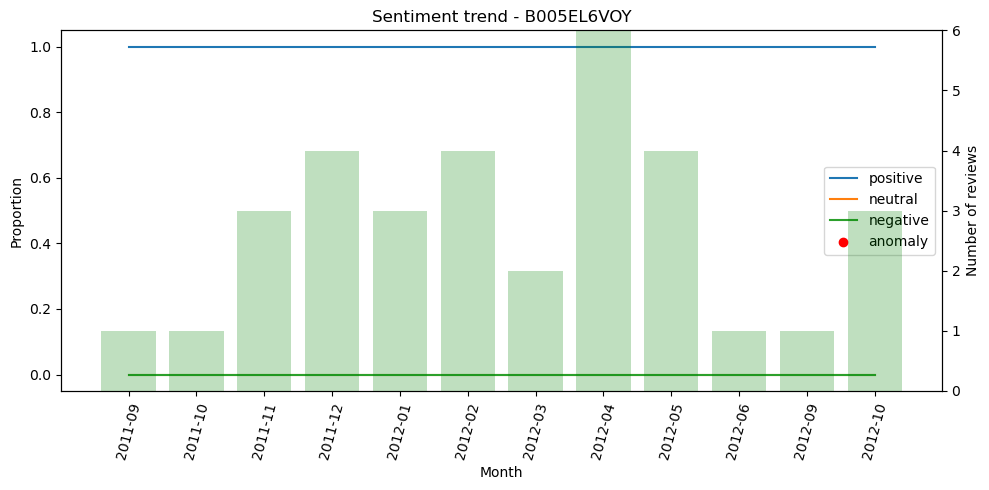

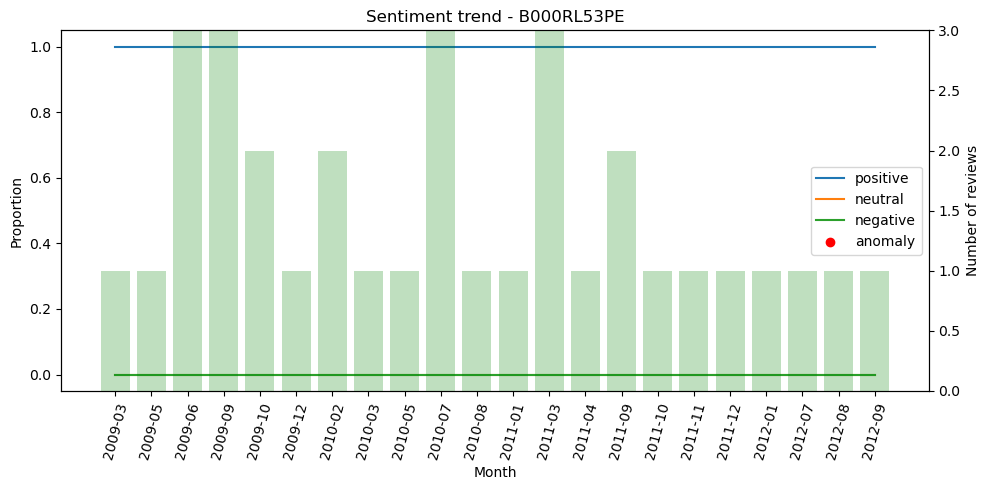


Anomaly detected for product B001IZ9ME6
sentiment  neg  neg_change
month                     
2010-12    0.5         inf


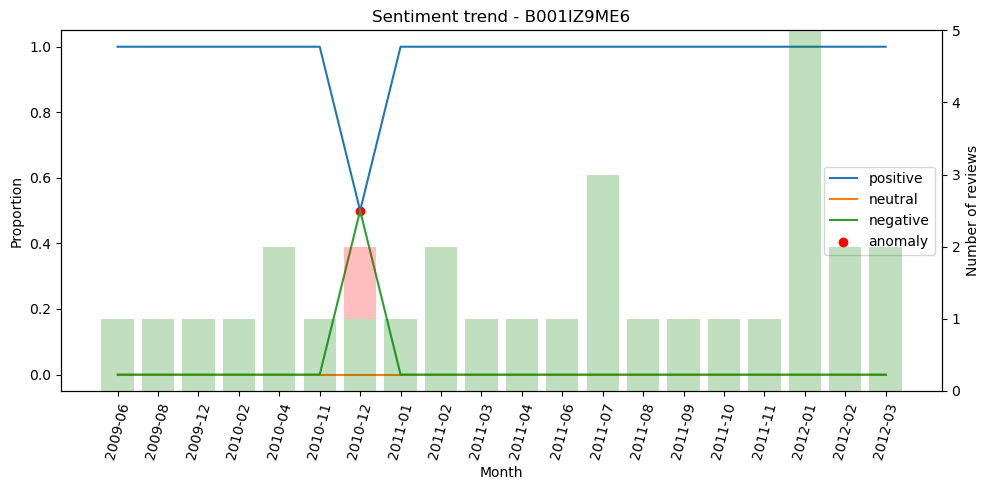


Anomaly detected for product B000ED9L9E
sentiment       neg  neg_change
month                          
2011-07    0.500000         inf
2012-10    0.090909         inf


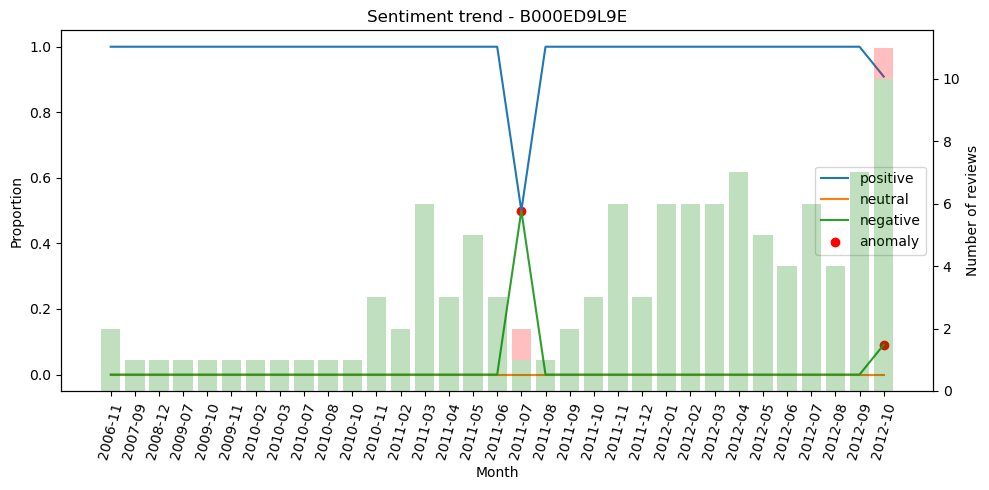


Anomaly detected for product B000FK7PQW
sentiment       neg  neg_change
month                          
2007-09    0.500000         inf
2009-11    0.333333         inf


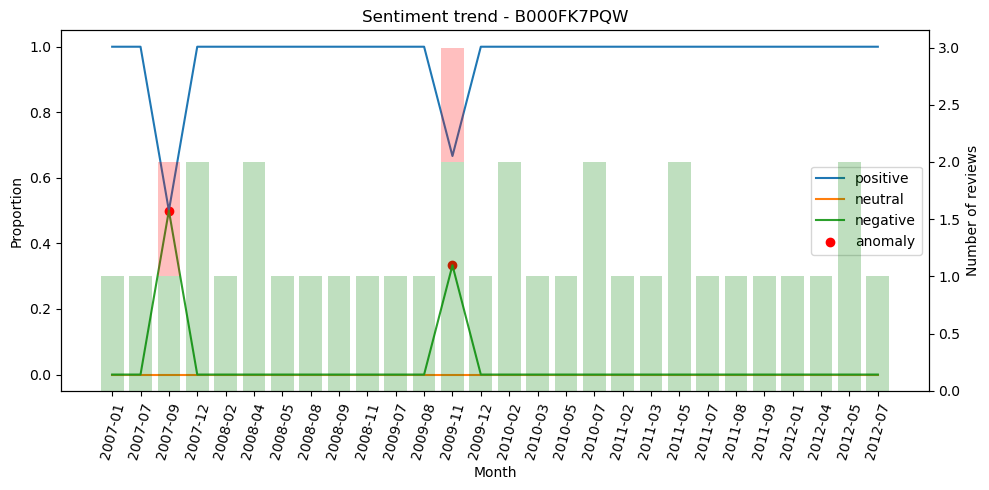

In [23]:
for product in top_products:

    subset = sentiment_monthly[
        sentiment_monthly["product_id"] == product
    ]

    pivot = subset.pivot_table(
        index="month",
        columns="sentiment",
        values="ratio",
        fill_value=0
    )

    # assicura sempre le 3 colonne
    for col in ["pos", "neu", "neg"]:
        if col not in pivot.columns:
            pivot[col] = 0

    pivot = pivot.sort_index()

    # conteggi mensili per sentiment
    monthly_sent_counts = (
        df[df["product_id"] == product]
        .groupby(["month", "sentiment"])
        .size()
        .unstack(fill_value=0)
        .reindex(pivot.index, fill_value=0)
    )

    # assicura sempre le 3 colonne anche nei conteggi
    for col in ["pos", "neu", "neg"]:
        if col not in monthly_sent_counts.columns:
            monthly_sent_counts[col] = 0

    monthly_sent_counts = monthly_sent_counts[["pos", "neu", "neg"]]

    # variazione percentuale del sentiment negativo
    pivot["neg_change"] = pivot["neg"].pct_change()
    anomalies = pivot[pivot["neg_change"] > 0.20]

    if not anomalies.empty:
        print(f"\nAnomaly detected for product {product}")
        print(anomalies[["neg", "neg_change"]])

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # linee proporzioni
    ax1.plot(pivot.index, pivot["pos"], label="positive")
    ax1.plot(pivot.index, pivot["neu"], label="neutral")
    ax1.plot(pivot.index, pivot["neg"], label="negative")
    ax1.scatter(anomalies.index, anomalies["neg"], color="red", label="anomaly")

    ax1.set_title(f"Sentiment trend - {product}")
    ax1.set_xlabel("Month")
    ax1.set_ylabel("Proportion")
    ax1.tick_params(axis="x", rotation=75)

    # seconda asse: istogramma stacked coi conteggi
    ax2 = ax1.twinx()
    ax2.bar(
        monthly_sent_counts.index,
        monthly_sent_counts["pos"],
        alpha=0.25,
        color="green"
    )
    ax2.bar(
        monthly_sent_counts.index,
        monthly_sent_counts["neu"],
        bottom=monthly_sent_counts["pos"],
        alpha=0.25,
        color="gray"
    )
    ax2.bar(
        monthly_sent_counts.index,
        monthly_sent_counts["neg"],
        bottom=monthly_sent_counts["pos"] + monthly_sent_counts["neu"],
        alpha=0.25,
        color="red"
    )
    ax2.set_ylabel("Number of reviews")

    # legenda solo per le linee + anomaly
    lines1, labels1 = ax1.get_legend_handles_labels()
    ax1.legend(lines1, labels1, loc="best")

    plt.tight_layout()
    plt.show()

#### 5.d)

##### Possibili cause

Le variazioni del sentiment nel tempo possono essere dovute a diversi fattori:

- cambiamenti nella qualità del prodotto

- modifiche nella composizione o nella produzione dell'azienda dovuto ad un possibile cambio della linea produttiva

- problemi nella distribuzione

- aspettative degli utenti o cambiamenti nel mercato

- cambiamento nei fornitori di materie prime o semi-lavorati

- cambiamento dovuto ad adattamenti a vari standard (AI-ACT), gestione privacy ecc

Un aumento improvviso del sentiment negativo potrebbe indicare un peggioramento percepito nella qualità del prodotto.

##### Adattamento del sistema di raccomandazione

Un sistema di raccomandazione potrebbe adattarsi a questi cambiamenti considerando il trend temporale del sentiment.
Ad esempio, se un prodotto mostra un aumento significativo delle recensioni negative negli ultimi mesi, il sistema potrebbe ridurre il peso di tale prodotto nelle raccomandazioni oppure favorire prodotti alternativi con un trend più positivo, così da evitare un danno di immagine dell'azienda data da un singolo prodotto fallimentare o in declino.